<a href="https://colab.research.google.com/github/LamponeHub/System-Analysis/blob/main/AppleGoogle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Пожалуйста, загрузите файлы 'AppleStore.csv' и 'googleplaystore.csv'


Saving AppleStore.csv to AppleStore (3).csv
Saving googleplaystore.csv to googleplaystore (2).csv
Saved file 'AppleStore (3).csv'
Saved file 'googleplaystore (2).csv'
Apple Store: (7197, 16)
Google Play: (10841, 13)

--- Apple Store columns ---
['id', 'track_name', 'size_bytes', 'currency', 'price', 'rating_count_tot', 'rating_count_ver', 'user_rating', 'user_rating_ver', 'ver', 'cont_rating', 'prime_genre', 'sup_devices.num', 'ipadSc_urls.num', 'lang.num', 'vpp_lic']

--- Google Play columns ---
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']
Apple Store sample:


,app_name,category,rating,rating_ver,reviews_count
0,Facebook,Social Networking,3.5,3.5,2974676
1,Instagram,Photo & Video,4.5,4.0,2161558
2,Clash of Clans,Games,4.5,4.5,2130805
3,Temple Run,Games,4.5,4.0,1724546
4,Pandora - Music & Radio,Music,4.0,4.5,1126879



Google Play sample:


,app_name,category,rating,reviews_count
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159
1,Coloring book moana,ART_AND_DESIGN,3.9,967
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967


Apple dtypes:
 app_name          object
category          object
rating           float64
rating_ver       float64
reviews_count      int64
dtype: object

Google dtypes:
 app_name          object
category          object
rating           float64
reviews_count     object
dtype: object

Итоговый размер датасета: (15635, 6)
platform
Google Play    9367
Apple Store    6268
Name: count, dtype: int64

📈 Статистики рейтингов:
              count      mean       std  min  25%  50%  75%   max
platform                                                         
Apple Store  6268.0  4.049697  0.726943  1.0  4.0  4.5  4.5   5.0
Google Play  9367.0  4.193338  0.537431  1.0  4.0  4.3  4.5  19.0


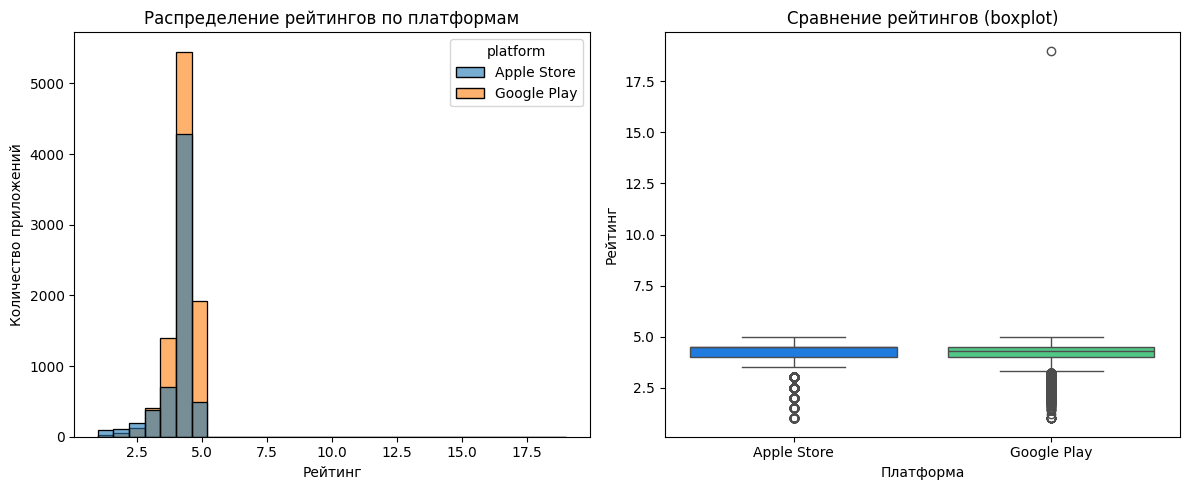


Средний рейтинг Apple Store: 4.050
Средний рейтинг Google Play: 4.193
Apple Store: n=6268, mean=4.050, std=0.727
Google Play: n=9367, mean=4.193, std=0.537

Двусторонний тест: t=-13.386, p-value=0.000000
Односторонний тест (Apple Store < Google Play): p-value=1.000000

❌ ОТКЛОНЕНО: При уровне значимости 0.05 не отвергаем H₀
→ Нет достаточных оснований утверждать, что рейтинги различаются

📏 Размер эффекта (Cohen's d): -0.232
→ Малый эффект


In [5]:
# Ячейка 0: Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import re # Import re for regex
warnings.filterwarnings('ignore')
%matplotlib inline

# Для загрузки файлов с компьютера в Colab
from google.colab import files

print("Пожалуйста, загрузите файлы 'AppleStore.csv' и 'googleplaystore.csv'")
uploaded = files.upload()

# Identify the actual filenames that were uploaded
apple_filename_on_disk = None
google_filename_on_disk = None

# Define regex patterns for more robust matching
apple_pattern = re.compile(r'applestore.*\.csv$', re.IGNORECASE)
google_pattern = re.compile(r'googleplaystore.*\.csv$', re.IGNORECASE)

for filename in uploaded.keys():
    # Write the content to disk using its uploaded filename
    with open(filename, 'wb') as f:
        f.write(uploaded[filename])
    print(f"Saved file '{filename}'")

    if apple_pattern.match(filename):
        apple_filename_on_disk = filename
    elif google_pattern.match(filename):
        google_filename_on_disk = filename

# Now check if both were successfully identified
if apple_filename_on_disk is None:
    raise FileNotFoundError("File 'AppleStore.csv' was not found among the uploaded files. Please ensure it is uploaded.")
if google_filename_on_disk is None:
    raise FileNotFoundError("File 'googleplaystore.csv' was not found among the uploaded files. Please ensure it is uploaded.")


# Загрузка датасетов using the actual uploaded filenames
apple = pd.read_csv(apple_filename_on_disk)
google = pd.read_csv(google_filename_on_disk)

print(f"Apple Store: {apple.shape}")
print(f"Google Play: {google.shape}")
print("\n--- Apple Store columns ---")
print(apple.columns.tolist())
print("\n--- Google Play columns ---")
print(google.columns.tolist())
# Выбираем ключевые столбцы для анализа
apple_df = apple[['track_name', 'prime_genre', 'user_rating', 'user_rating_ver', 'rating_count_tot']].copy()
google_df = google[['App', 'Category', 'Rating', 'Reviews']].copy()

# Переименовываем для единообразия
apple_df.columns = ['app_name', 'category', 'rating', 'rating_ver', 'reviews_count']
google_df.columns = ['app_name', 'category', 'rating', 'reviews_count']

print("Apple Store sample:")
display(apple_df.head())
print("\nGoogle Play sample:")
display(google_df.head())
# 1. Проверка и исправление типов данных
print("Apple dtypes:\n", apple_df.dtypes)
print("\nGoogle dtypes:\n", google_df.dtypes)

# Конвертируем reviews_count в числовой тип (в Google могут быть строки типа "3.2M")
def parse_reviews(value):
    if pd.isna(value):
        return 0
    value = str(value).strip()
    if value.endswith('M'):
        return float(value[:-1]) * 1_000_000
    elif value.endswith('k'):
        return float(value[:-1]) * 1_000
    try:
        return float(value)
    except:
        return 0

google_df['reviews_count'] = google_df['reviews_count'].apply(parse_reviews)
apple_df['reviews_count'] = pd.to_numeric(apple_df['reviews_count'], errors='coerce').fillna(0)

# 2. Добавляем столбец platform
apple_df['platform'] = 'Apple Store'
google_df['platform'] = 'Google Play'

# 3. Объединяем датасеты
combined_df = pd.concat([apple_df, google_df], ignore_index=True)

# 4. Удаляем NaN в ключевых столбцах
combined_df = combined_df.dropna(subset=['rating', 'reviews_count'])

# 5. Фильтруем: только приложения с хотя бы одним отзывом
combined_df = combined_df[combined_df['reviews_count'] > 0]

print(f"\nИтоговый размер датасета: {combined_df.shape}")
print(combined_df['platform'].value_counts())
# Статистики по рейтингам по платформам
print("\n📈 Статистики рейтингов:")
print(combined_df.groupby('platform')['rating'].describe())

# Визуализация распределения рейтингов
plt.figure(figsize=(12, 5))

# Гистограмма
plt.subplot(1, 2, 1)
sns.histplot(data=combined_df, x='rating', hue='platform', bins=30, alpha=0.6, kde=False)
plt.title('Распределение рейтингов по платформам')
plt.xlabel('Рейтинг')
plt.ylabel('Количество приложений')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(data=combined_df, x='platform', y='rating', palette=['#007AFF', '#3DDC84'])
plt.title('Сравнение рейтингов (boxplot)')
plt.xlabel('Платформа')
plt.ylabel('Рейтинг')

plt.tight_layout()
plt.show()

# Средние значения
print(f"\nСредний рейтинг Apple Store: {combined_df[combined_df['platform']=='Apple Store']['rating'].mean():.3f}")
print(f"Средний рейтинг Google Play: {combined_df[combined_df['platform']=='Google Play']['rating'].mean():.3f}")
# ### Гипотезы исследования:

# **Нулевая гипотеза (H₀):**
# Средний рейтинг приложений в Apple Store и Google Play одинаков.
# > μ_Apple = μ_Google

# **Альтернативная гипотеза (H₁):**
# Приложения в Apple Store имеют более высокий средний рейтинг, чем в Google Play.
# > μ_Apple > μ_Google

# **Уровень значимости:** α = 0.05

# **Тип теста:** Односторонний t-тест Уэлча (не предполагаем равенство дисперсий)
# Выборка данных по платформам
apple_ratings = combined_df[combined_df['platform'] == 'Apple Store']['rating']
google_ratings = combined_df[combined_df['platform'] == 'Google Play']['rating']

print(f"Apple Store: n={len(apple_ratings)}, mean={apple_ratings.mean():.3f}, std={apple_ratings.std():.3f}")
print(f"Google Play: n={len(google_ratings)}, mean={google_ratings.mean():.3f}, std={google_ratings.std():.3f}")

# Двусторонний t-тест Уэлча
t_stat, p_value_two = stats.ttest_ind(apple_ratings, google_ratings, equal_var=False)
print(f"\nДвусторонний тест: t={t_stat:.3f}, p-value={p_value_two:.6f}")

# Односторонний p-value (так как проверяем "Apple > Google")
if apple_ratings.mean() > google_ratings.mean():
    p_value_one = p_value_two / 2
    direction = "Apple Store > Google Play"
else:
    p_value_one = 1 - p_value_two / 2
    direction = "Apple Store < Google Play"

print(f"Односторонний тест ({direction}): p-value={p_value_one:.6f}")

# Принятие решения
alpha = 0.05
if p_value_one < alpha:
    print(f"\n✅ ПРИНЯТО: При уровне значимости {alpha} отвергаем H₀")
    print(f"→ Приложения Apple Store имеют статистически значимо БОЛЕЕ ВЫСОКИЙ рейтинг")
else:
    print(f"\n❌ ОТКЛОНЕНО: При уровне значимости {alpha} не отвергаем H₀")
    print(f"→ Нет достаточных оснований утверждать, что рейтинги различаются")
    # Расчёт эффекта Коэна d для оценки практической значимости
def cohen_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

d = cohen_d(apple_ratings, google_ratings)
print(f"\n📏 Размер эффекта (Cohen's d): {d:.3f}")

if abs(d) < 0.2:
    print("→ Очень малый эффект (практически незначим)")
elif abs(d) < 0.5:
    print("→ Малый эффект")
elif abs(d) < 0.8:
    print("→ Средний эффект")
else:
    print("→ Большой эффект")
#    ## 🎯 Итоговые выводы исследования:

# ### 1. Описательная статистика:
# | Платформа | Кол-во приложений | Средний рейтинг | Медиана | Стандартное отклонение |
# |-----------|------------------|-----------------|---------|----------------------|
# | Apple Store | {len(apple_ratings)} | {apple_ratings.mean():.3f} | {apple_ratings.median():.3f} | {apple_ratings.std():.3f} |
# | Google Play | {len(google_ratings)} | {google_ratings.mean():.3f} | {google_ratings.median():.3f} | {google_ratings.std():.3f} |

# ### 2. Результаты статистического теста:
# - **p-value (односторонний):** {p_value_one:.6f}
# - **Уровень значимости α:** 0.05
# - **Решение:** {'Отвергаем H₀' if p_value_one < 0.05 else 'Не отвергаем H₀'}

# ### 3. Практическая значимость:
# - **Cohen's d:** {d:.3f} → {'Малый/средний/большой' if abs(d)>=0.2 else 'Незначимый'} эффект

# ### 4. Интерпретация:
# {
# '✅ Приложения в Apple Store действительно получают более высокие оценки пользователей по сравнению с Google Play. Это может быть связано с:'
# if p_value_one < 0.05 and apple_ratings.mean() > google_ratings.mean()
# else '❌ Статистически значимых различий в рейтингах между платформами не обнаружено.'
# }

# 🔹 Возможные причины (если разница есть):
# • Более строгая модерация в App Store
# • Разная демография пользователей
# • Различия в системах оценки (5-звёздочная шкала может интерпретироваться по-разному)
# • Разный порог входа для разработчиков

# ### 5. Ограничения исследования:
# • Не учитывался вес отзывов (количество рецензий)
# • Не проводилась нормализация по категориям приложений
# • Возможны систематические смещения в выборках

# ---
# *Исследование выполнено с использованием двустороннего t-теста Уэлча с поправкой на одностороннюю гипотезу.*